<a href="https://colab.research.google.com/github/Chikka-Pradhayani/ABTalks-60-Days-AI-Challenge/blob/main/Day_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries if needed
!pip install scikit-learn numpy matplotlib -q

# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 2: Create the text corpus

corpus = [
    # Animals
    "The dog is playing in the garden.",
    "A puppy is running around the yard.",
    "The cat is sleeping on the sofa.",
    "Dogs and puppies are friendly animals.",

    # Technology
    "Artificial intelligence is transforming technology.",
    "Machine learning helps computers learn from data.",
    "Python is widely used for artificial intelligence.",

    # Travel and Transport
    "The airplane is flying across the sky.",
    "Passengers are waiting at the airport.",
    "Travellers are preparing for their flight."
]

# Display all sentences
for i, sentence in enumerate(corpus):
    print(f"{i}: {sentence}")

0: The dog is playing in the garden.
1: A puppy is running around the yard.
2: The cat is sleeping on the sofa.
3: Dogs and puppies are friendly animals.
4: Artificial intelligence is transforming technology.
5: Machine learning helps computers learn from data.
6: Python is widely used for artificial intelligence.
7: The airplane is flying across the sky.
8: Passengers are waiting at the airport.
9: Travellers are preparing for their flight.


In [3]:
# Step 3: Convert sentences into TF-IDF vectors

# Create the TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Transform the corpus into numerical vectors
tfidf_matrix = vectorizer.fit_transform(corpus)

# Convert the sparse matrix into a normal NumPy array
tfidf_array = tfidf_matrix.toarray()

print("TF-IDF Matrix Shape:", tfidf_array.shape)

TF-IDF Matrix Shape: (10, 47)


In [4]:
# Display the words/features recognized by TF-IDF

features = vectorizer.get_feature_names_out()

print("Number of features:", len(features))
print("\nVocabulary:")
print(features)

Number of features: 47

Vocabulary:
['across' 'airplane' 'airport' 'and' 'animals' 'are' 'around' 'artificial'
 'at' 'cat' 'computers' 'data' 'dog' 'dogs' 'flight' 'flying' 'for'
 'friendly' 'from' 'garden' 'helps' 'in' 'intelligence' 'is' 'learn'
 'learning' 'machine' 'on' 'passengers' 'playing' 'preparing' 'puppies'
 'puppy' 'python' 'running' 'sky' 'sleeping' 'sofa' 'technology' 'the'
 'their' 'transforming' 'travellers' 'used' 'waiting' 'widely' 'yard']


In [5]:
# Display TF-IDF vector for each sentence

for i, vector in enumerate(tfidf_array):
    print(f"\nSentence {i}:")
    print(corpus[i])
    print("Vector:")
    print(vector)


Sentence 0:
The dog is playing in the garden.
Vector:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.41890251 0.         0.         0.         0.         0.
 0.         0.41890251 0.         0.41890251 0.         0.22487869
 0.         0.         0.         0.         0.         0.41890251
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.49750609 0.         0.
 0.         0.         0.         0.         0.        ]

Sentence 1:
A puppy is running around the yard.
Vector:
[0.         0.         0.         0.         0.         0.
 0.46419794 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.24919456
 0.         0.         0.         0.         0.         0.
 0.         0.         0.46419794 0.         0.46419794 0.
 0.         0.         0.         0.2756

In [7]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print("Similarity Matrix Shape:", similarity_matrix.shape)
print("\nCosine Similarity Matrix:\n")
print(np.round(similarity_matrix, 2))

Similarity Matrix Shape: (10, 10)

Cosine Similarity Matrix:

[[1.   0.19 0.3  0.   0.06 0.   0.05 0.3  0.13 0.  ]
 [0.19 1.   0.19 0.   0.07 0.   0.06 0.19 0.07 0.  ]
 [0.3  0.19 1.   0.   0.06 0.   0.05 0.3  0.13 0.  ]
 [0.   0.   0.   1.   0.   0.   0.   0.   0.11 0.1 ]
 [0.06 0.07 0.06 0.   1.   0.   0.38 0.06 0.   0.  ]
 [0.   0.   0.   0.   0.   1.   0.   0.   0.   0.  ]
 [0.05 0.06 0.05 0.   0.38 0.   1.   0.05 0.   0.13]
 [0.3  0.19 0.3  0.   0.06 0.   0.05 1.   0.13 0.  ]
 [0.13 0.07 0.13 0.11 0.   0.   0.   0.13 1.   0.11]
 [0.   0.   0.   0.1  0.   0.   0.13 0.   0.11 1.  ]]


In [8]:
pairs = [
    (0, 3),  # Dog sentence vs dogs/puppies sentence
    (4, 6),  # AI sentence vs Python/AI sentence
    (7, 9),  # Airplane sentence vs flight sentence
    (0, 7)   # Dog sentence vs airplane sentence
]
for i, j in pairs:
    score = similarity_matrix[i][j]
    print(f"\nSentence {i}: {corpus[i]}")
    print(f"Sentence {j}: {corpus[j]}")
    print(f"Cosine Similarity: {score:.4f}")


Sentence 0: The dog is playing in the garden.
Sentence 3: Dogs and puppies are friendly animals.
Cosine Similarity: 0.0000

Sentence 4: Artificial intelligence is transforming technology.
Sentence 6: Python is widely used for artificial intelligence.
Cosine Similarity: 0.3841

Sentence 7: The airplane is flying across the sky.
Sentence 9: Travellers are preparing for their flight.
Cosine Similarity: 0.0000

Sentence 0: The dog is playing in the garden.
Sentence 7: The airplane is flying across the sky.
Cosine Similarity: 0.2981


In [9]:
def find_similar(query, corpus, top_k=3):
    """
    Find the most similar sentences in the corpus
    using TF-IDF and cosine similarity.
    """
    vectorizer = TfidfVectorizer()
    corpus_vectors = vectorizer.fit_transform(corpus)
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, corpus_vectors)[0]
    ranked_indices = np.argsort(scores)[::-1]
    results = []
    for index in ranked_indices[:top_k]:
        results.append((corpus[index], scores[index]))
    return results

In [10]:
query = "A dog is running in the garden."
results = find_similar(query, corpus, top_k=3)
print("Query:", query)
print("\nMost Similar Sentences:\n")
for sentence, score in results:
    print(f"Score: {score:.4f} → {sentence}")

Query: A dog is running in the garden.

Most Similar Sentences:

Score: 0.7765 → The dog is playing in the garden.
Score: 0.3536 → A puppy is running around the yard.
Score: 0.1932 → The airplane is flying across the sky.


In [11]:
queries = [
    "Dogs are friendly animals.",
    "Artificial intelligence and machine learning",
    "A passenger is waiting for an airplane."
]
for query in queries:
    print("\n" + "=" * 60)
    print("QUERY:", query)
    results = find_similar(query, corpus, top_k=3)
    for sentence, score in results:
        print(f"{score:.4f} → {sentence}")


QUERY: Dogs are friendly animals.
0.7999 → Dogs and puppies are friendly animals.
0.1325 → Passengers are waiting at the airport.
0.1278 → Travellers are preparing for their flight.

QUERY: Artificial intelligence and machine learning
0.3585 → Machine learning helps computers learn from data.
0.3548 → Artificial intelligence is transforming technology.
0.2935 → Python is widely used for artificial intelligence.

QUERY: A passenger is waiting for an airplane.
0.3110 → The airplane is flying across the sky.
0.2602 → Passengers are waiting at the airport.
0.2494 → Python is widely used for artificial intelligence.


In [12]:
test_corpus = [
    "The dog is a friendly animal.",
    "The puppy is a young dog.",
    "The dog loves playing in the park.",
    "The airplane is flying in the sky.",
    "Passengers are waiting for the airplane."
]

In [13]:
def compare_sentences(sentence1, sentence2):
    """
    Calculate cosine similarity between two sentences.
    """
    vectorizer = TfidfVectorizer()
    vectors = vectorizer.fit_transform([
        sentence1,
        sentence2
    ])
    score = cosine_similarity(vectors[0], vectors[1])[0][0]
    return score

In [14]:
dog = "The dog is a friendly animal."
puppy = "The puppy is a young dog."
dog_puppy_score = compare_sentences(dog, puppy)
print("Dog vs Puppy")
print(f"Cosine Similarity: {dog_puppy_score:.4f}")

Dog vs Puppy
Cosine Similarity: 0.4316


In [15]:
airplane = "The airplane is flying in the sky."
dog_airplane_score = compare_sentences(dog, airplane)
print("Dog vs Airplane")
print(f"Cosine Similarity: {dog_airplane_score:.4f}")

Dog vs Airplane
Cosine Similarity: 0.2967


In [16]:
test_pairs = [
    ("Dog", dog, "Puppy", puppy),
    ("Dog", dog, "Airplane", airplane),
    (
        "Artificial Intelligence",
        "Artificial intelligence is transforming technology.",
        "Machine Learning",
        "Machine learning helps computers learn from data."
    ),
    (
        "Airplane",
        airplane,
        "Airport",
        "Passengers are waiting at the airport."
    )
]
print("COSINE SIMILARITY TEST RESULTS")
print("=" * 50)
for name1, sentence1, name2, sentence2 in test_pairs:
    score = compare_sentences(sentence1, sentence2)
    print(f"{name1} vs {name2}: {score:.4f}")

COSINE SIMILARITY TEST RESULTS
Dog vs Puppy: 0.4316
Dog vs Airplane: 0.2967
Artificial Intelligence vs Machine Learning: 0.0000
Airplane vs Airport: 0.1628


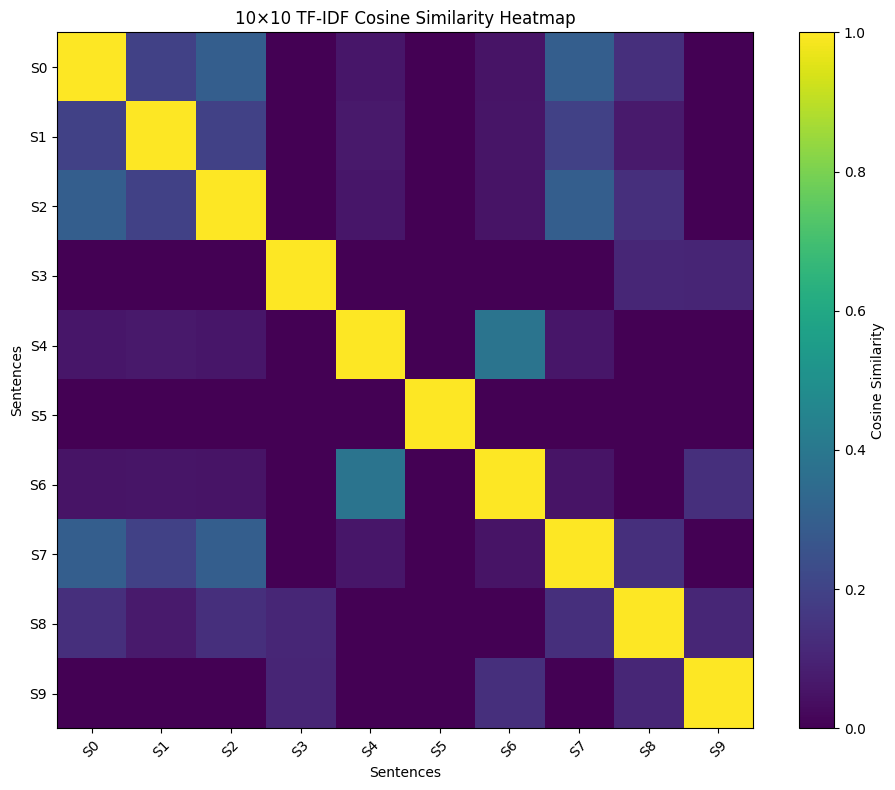

In [17]:
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, interpolation="nearest")
plt.colorbar(label="Cosine Similarity")
plt.xticks(
    range(len(corpus)),
    [f"S{i}" for i in range(len(corpus))],
    rotation=45
)
plt.yticks(
    range(len(corpus)),
    [f"S{i}" for i in range(len(corpus))]
)
plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.title("10×10 TF-IDF Cosine Similarity Heatmap")
plt.tight_layout()
plt.show()

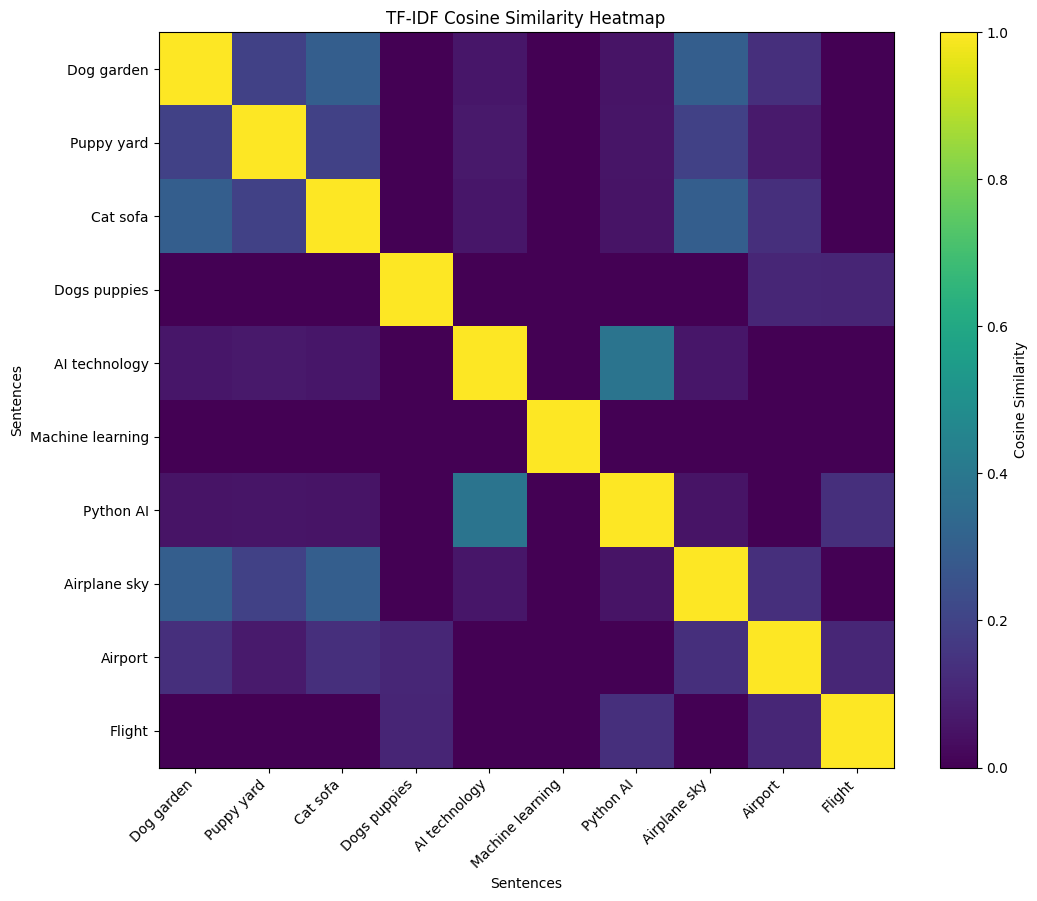

In [18]:
labels = [
    "Dog garden",
    "Puppy yard",
    "Cat sofa",
    "Dogs puppies",
    "AI technology",
    "Machine learning",
    "Python AI",
    "Airplane sky",
    "Airport",
    "Flight"
]
plt.figure(figsize=(11, 9))
plt.imshow(similarity_matrix, interpolation="nearest")
plt.colorbar(label="Cosine Similarity")
plt.xticks(
    range(len(corpus)),
    labels,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(corpus)),
    labels
)
plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.title("TF-IDF Cosine Similarity Heatmap")
plt.tight_layout()
plt.show()

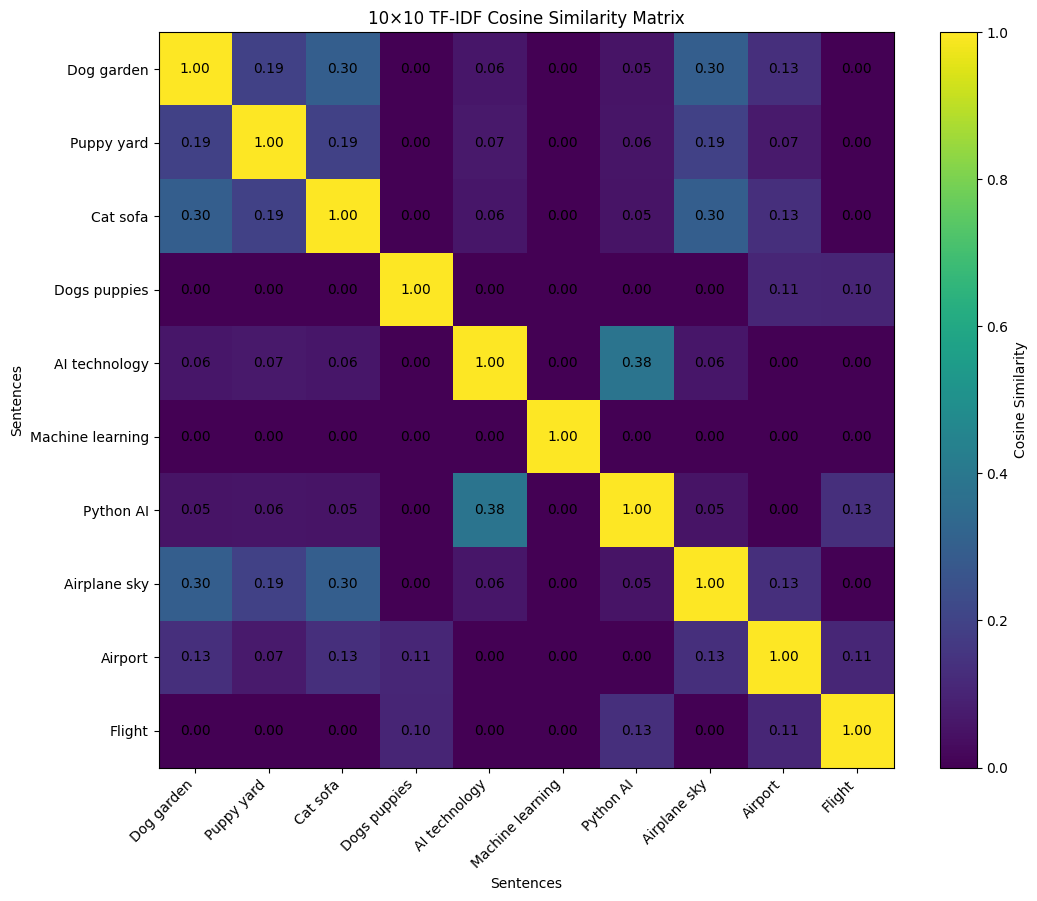

In [19]:
plt.figure(figsize=(11, 9))
plt.imshow(similarity_matrix, interpolation="nearest")
plt.colorbar(label="Cosine Similarity")
plt.xticks(
    range(len(corpus)),
    labels,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(corpus)),
    labels
)
# Display similarity values
for i in range(len(corpus)):
    for j in range(len(corpus)):
        plt.text(
            j,
            i,
            f"{similarity_matrix[i, j]:.2f}",
            ha="center",
            va="center"
        )
plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.title("10×10 TF-IDF Cosine Similarity Matrix")
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

tfidf_df = pd.DataFrame(
    tfidf_array,
    columns=vectorizer.get_feature_names_out()
)

tfidf_df.index = [f"S{i}" for i in range(len(corpus))]

display(tfidf_df.round(2))

,across,airplane,airport,and,animals,are,around,artificial,at,cat,...,sofa,technology,the,their,transforming,travellers,used,waiting,widely,yard
S0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00
S1,0.00,0.00,0.00,0.00,0.00,0.00,0.46,0.00,0.00,0.00,...,0.00,0.00,0.28,0.00,0.00,0.00,0.00,0.00,0.00,0.46
S2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.42,...,0.42,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00
S3,0.00,0.00,0.00,0.42,0.42,0.32,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
S4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.44,0.00,0.00,...,0.00,0.52,0.00,0.00,0.52,0.00,0.00,0.00,0.00,0.00
S5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
S6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.36,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.43,0.00,0.43,0.00
S7,0.42,0.42,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00
S8,0.00,0.00,0.45,0.00,0.00,0.34,0.00,0.00,0.45,0.00,...,0.00,0.00,0.27,0.00,0.00,0.00,0.00,0.45,0.00,0.00
S9,0.00,0.00,0.00,0.00,0.00,0.32,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.44,0.00,0.44,0.00,0.00,0.00,0.00


In [21]:
print("Number of sentences:", len(corpus))
print("Similarity matrix shape:", similarity_matrix.shape)

assert similarity_matrix.shape == (10, 10)

print("✓ 10×10 similarity matrix verified!")

Number of sentences: 10
Similarity matrix shape: (10, 10)
✓ 10×10 similarity matrix verified!


In [22]:
print("Most Similar Sentence for Each Sentence")
print("=" * 60)

for i in range(len(corpus)):
    scores = similarity_matrix[i].copy()

    # Ignore the sentence itself
    scores[i] = -1

    most_similar_index = np.argmax(scores)

    print(f"\nS{i}: {corpus[i]}")
    print(
        f"→ Most similar: S{most_similar_index}: "
        f"{corpus[most_similar_index]}"
    )
    print(f"→ Score: {scores[most_similar_index]:.4f}")

Most Similar Sentence for Each Sentence

S0: The dog is playing in the garden.
→ Most similar: S2: The cat is sleeping on the sofa.
→ Score: 0.2981

S1: A puppy is running around the yard.
→ Most similar: S0: The dog is playing in the garden.
→ Score: 0.1932

S2: The cat is sleeping on the sofa.
→ Most similar: S0: The dog is playing in the garden.
→ Score: 0.2981

S3: Dogs and puppies are friendly animals.
→ Most similar: S8: Passengers are waiting at the airport.
→ Score: 0.1060

S4: Artificial intelligence is transforming technology.
→ Most similar: S6: Python is widely used for artificial intelligence.
→ Score: 0.3841

S5: Machine learning helps computers learn from data.
→ Most similar: S0: The dog is playing in the garden.
→ Score: 0.0000

S6: Python is widely used for artificial intelligence.
→ Most similar: S4: Artificial intelligence is transforming technology.
→ Score: 0.3841

S7: The airplane is flying across the sky.
→ Most similar: S0: The dog is playing in the garden.
→ S

In [23]:
test_queries = [
    "A dog is playing outside.",
    "AI systems learn from data.",
    "A passenger is travelling by airplane.",
    "A cat is resting at home."
]

for query in test_queries:
    print("\n" + "=" * 70)
    print("QUERY:", query)

    results = find_similar(query, corpus, top_k=3)

    for rank, (sentence, score) in enumerate(results, start=1):
        print(f"{rank}. {score:.4f} → {sentence}")


QUERY: A dog is playing outside.
1. 0.6337 → The dog is playing in the garden.
2. 0.0986 → Artificial intelligence is transforming technology.
3. 0.0884 → A puppy is running around the yard.

QUERY: AI systems learn from data.
1. 0.6547 → Machine learning helps computers learn from data.
2. 0.0000 → Travellers are preparing for their flight.
3. 0.0000 → Passengers are waiting at the airport.

QUERY: A passenger is travelling by airplane.
1. 0.4754 → The airplane is flying across the sky.
2. 0.1314 → Artificial intelligence is transforming technology.
3. 0.1179 → A puppy is running around the yard.

QUERY: A cat is resting at home.
1. 0.3567 → The cat is sleeping on the sofa.
2. 0.2985 → Passengers are waiting at the airport.
3. 0.0986 → Artificial intelligence is transforming technology.
